In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

import sim_ranking as sr
import ml_tools as mlt


In [2]:
emp_cim_dir = Path("/Users/claudy/dev/work/data/sim_ranking/results/20240301_comparison/synthethic/emp_cIM_perturbed_100r")
ml_data_dir = Path("/Users/claudy/dev/work/data/sim_ranking/results/20240301_comparison/synthethic/0423_1449_lb_30_100_SCweighted_probL2_0p5")

db_ffp = Path("/Users/claudy/dev/work/data/sim_ranking/emp_realisations/perturbed_0313_100r/gm_db_emp.sqlite")
im_wavg_cols = mlt.array_utils.numpy_str_join("_", sr.constants.PSA_KEYS, "wavg")

In [3]:
def load_cim_data(data_dir: Path, event: str):
	result_ffp = data_dir / event / "empirical_cMVN/cMVN_distributions.pickle"
	return sr.conditional.ConditionalMVNDistribution.load(result_ffp)

In [7]:
meta = mlt.utils.load_yaml(ml_data_dir / "meta.yaml")
run_config = sr.ml.sc_prob.RunParamsConfig.from_dict(meta["run_config"])

val_sc_sum_df = pd.read_parquet(ml_data_dir / "val_scenario_summary.parquet")
val_sc_df = pd.read_parquet(ml_data_dir / "val_scenario_results.parquet")

db = sr.db.DB(db_ffp)

In [8]:
cur_event = "2013p750727"
cur_site_int = "ARKS"

In [9]:
cur_emp_cim = load_cim_data(emp_cim_dir, cur_event)
cur_sc_df = val_sc_df[(val_sc_df["event_id"] == cur_event) & (val_sc_df["site_int"] == cur_site_int)].sort_index()
cur_sim_data = db.get_sim_data(cur_event, [cur_site_int]).sort_index()

assert np.all(cur_sc_df.index == cur_sim_data.index)

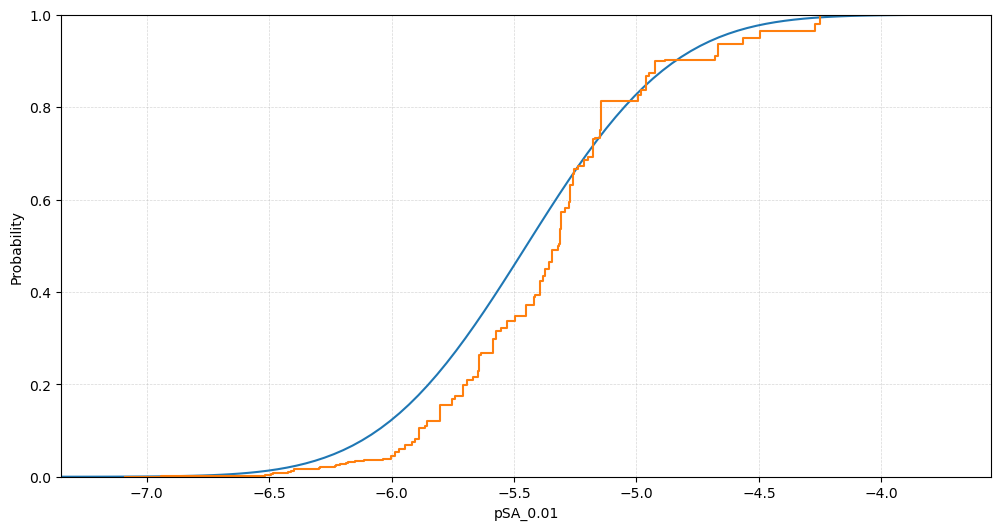

In [15]:
# Plot the cdf

cur_im = "pSA_0.01"

### cIM
# Get mu and sigma
cur_cim_mu = cur_emp_cim.cond_lnIM_mean_df.loc[cur_site_int, cur_im]
cur_cim_sigma = cur_emp_cim.cond_lnIM_std_df.loc[cur_site_int, cur_im]
# Create values
cim_im_values = np.linspace(cur_cim_mu - 4 * cur_cim_sigma, cur_cim_mu + 4 * cur_cim_sigma, 100)
cim_prob_values = stats.norm.cdf(cim_im_values, cur_cim_mu, cur_cim_sigma)

### ML
# Get values
ml_im_values = np.log(cur_sim_data[cur_im].values.astype(float))
ml_prob_values = cur_sc_df[f"{cur_im}_prob"]
# Sort
sort_int = np.argsort(ml_im_values)
ml_im_values = ml_im_values[sort_int]
ml_cum_prob_values = np.cumsum(ml_prob_values.values[sort_int])

# Plot the CDF
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(cim_im_values, cim_prob_values, label="cIM CDF")
ax.step(ml_im_values, ml_cum_prob_values)

ax.set_xlabel(f"{cur_im}")
ax.set_ylabel(f"Probability")
ax.set_ylim(0, 1)
ax.set_xlim(cim_im_values.min(), cim_im_values.max())
ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")

### Null Hypothesis
Drawn from the same distribution
Large p-value (> 0.05)
 

### Alternate Hypothesis
Not drawn from the same distribution
Small p-value (< 0.05)

In [11]:
# KS Test
stats.kstest(ml_im_values, "norm", args=(cur_cim_mu, cur_cim_sigma))

KstestResult(statistic=0.27996919336351117, pvalue=2.0036651084964274e-07)

In [12]:
def weighted_ks_test(ml_im_values: np.ndarray, ml_cum_prob_values: np.ndarray, cim_mu: float, cim_sigma: float):
	cim_cdf = stats.norm.cdf(ml_im_values, cim_mu, cim_sigma)
	ks_stats = np.max(np.abs(ml_cum_prob_values - cim_cdf)) * np.sqrt(ml_im_values.size) 
	p_value = stats.kstwobign.sf(ks_stats)
	return ks_stats, p_value

In [13]:
weighted_ks_test(ml_im_values, ml_cum_prob_values, cur_cim_mu, cur_cim_sigma)

(1.5332510590178938, 0.018159322969292416)

In [18]:
# Compute KS-statistic and p-values
ks_df, p_df = sr.ml.sc_prob.compute_ks_p_values(val_sc_df, emp_cim_dir, db_ffp, run_config)

## P-Value Results

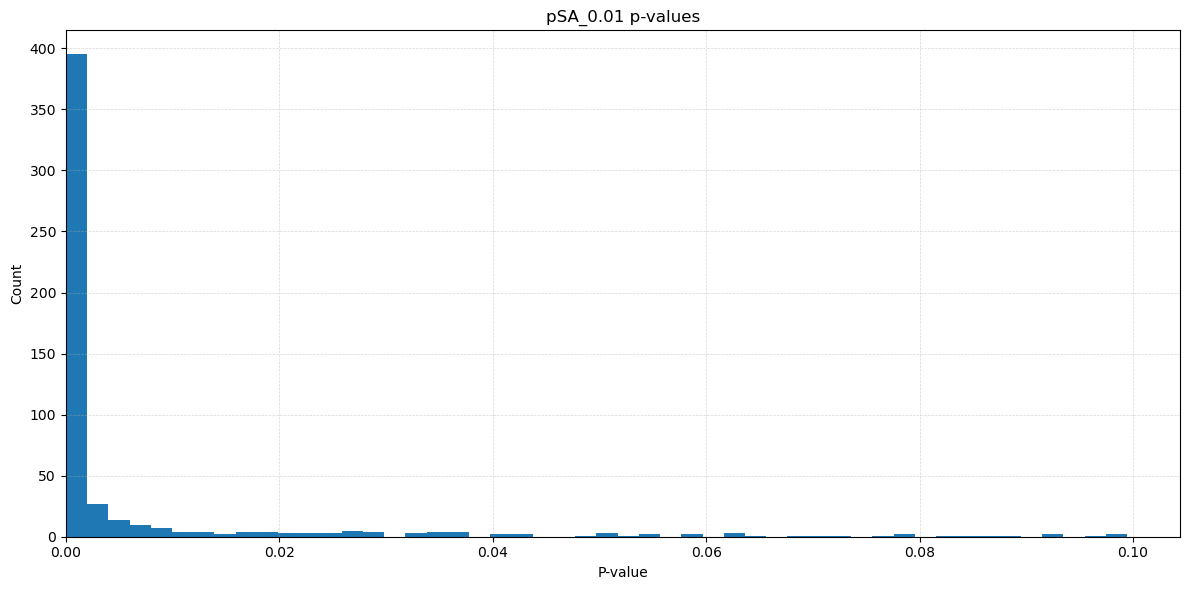

In [25]:
cur_im = "pSA_0.01"

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(p_df[cur_im].loc[p_df[cur_im] < 0.1].values, bins=50)

ax.set_title(f"{cur_im} p-values")
ax.set_xlabel(f"P-value")
ax.set_ylabel(f"Count")
ax.set_xlim(0, None)
ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")

fig.tight_layout()

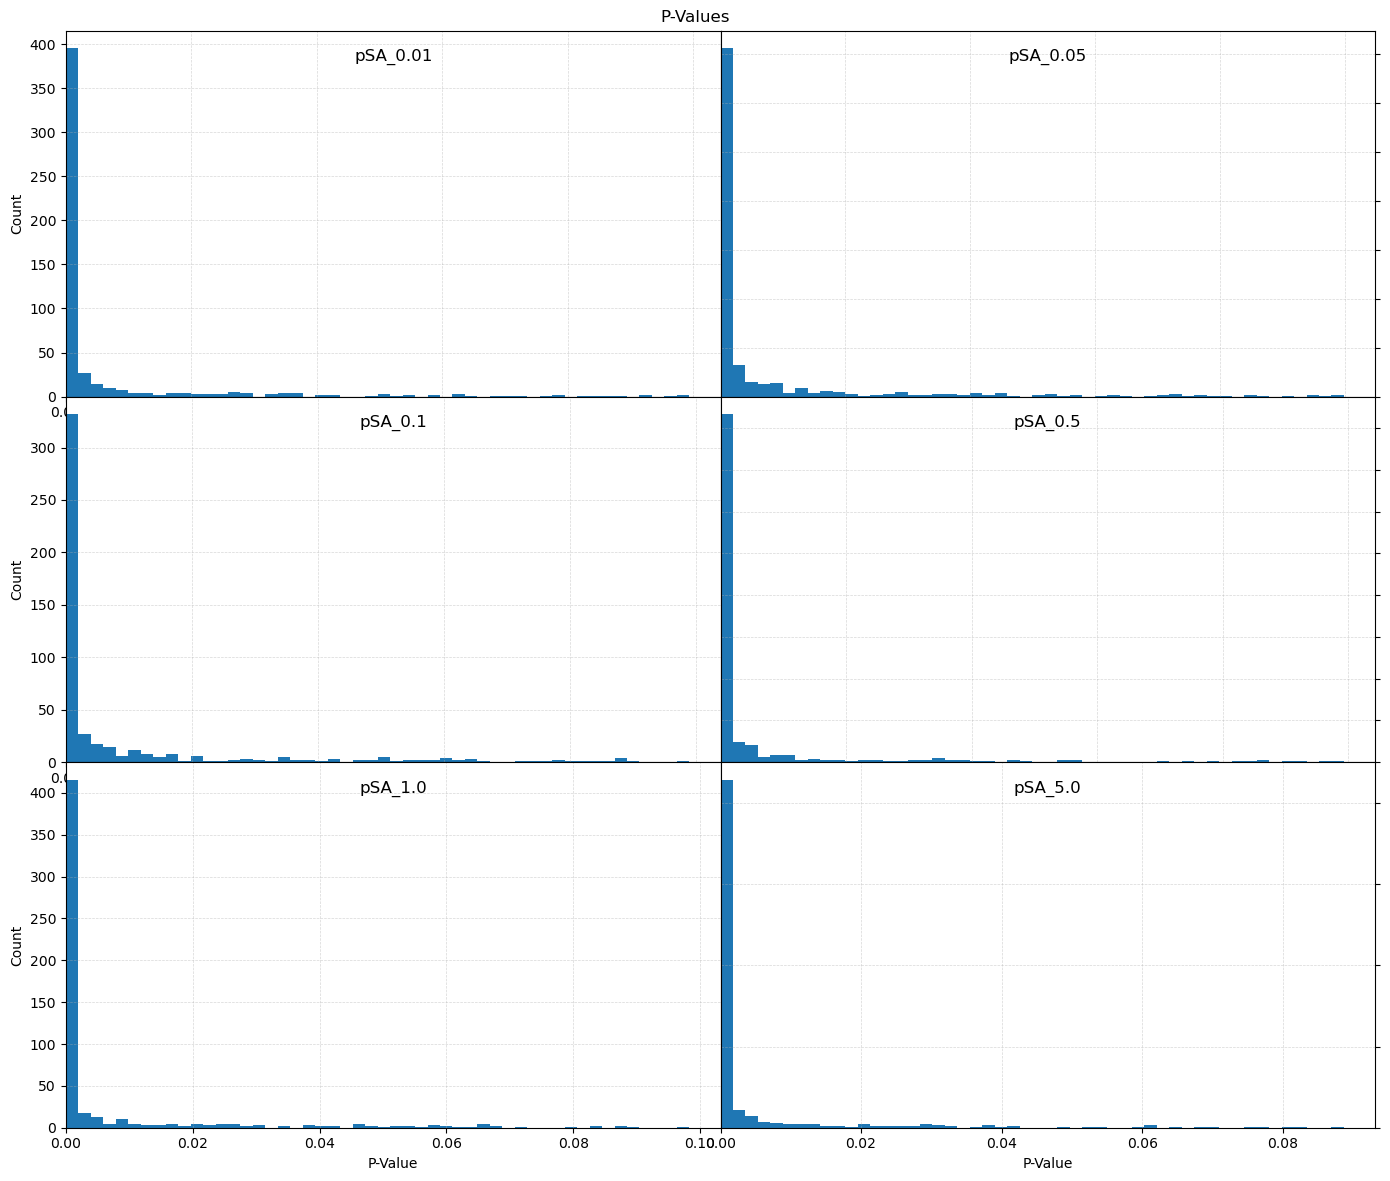

In [33]:
ims = ["pSA_0.01", "pSA_0.05", "pSA_0.1", "pSA_0.5", "pSA_1.0", "pSA_5.0"]

fig, axs = plt.subplots(3, 2, figsize=(14, 12))

for ix, (cur_ax, cur_im) in enumerate(zip(axs.ravel(), ims)):
	cur_ax.hist(p_df[cur_im].loc[p_df[cur_im] < 0.1].values, bins=50)
	cur_ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")
	
	if ix >= 4:
		cur_ax.set_xlabel(f"P-Value")
	if ix % 2 == 0:
		cur_ax.set_ylabel(f"Count")
		
	if ix % 2 == 1:
		cur_ax.set_yticklabels([])
		cur_ax.yaxis.tick_right()

	cur_ax.set_xlim(0, None)
	
	cur_ax.text(0.5, 0.95, f"{cur_im}", horizontalalignment="center", verticalalignment="top", transform=cur_ax.transAxes, fontsize=12)
	
	
fig.suptitle("P-Values")
fig.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)

## KS-Statistic Results

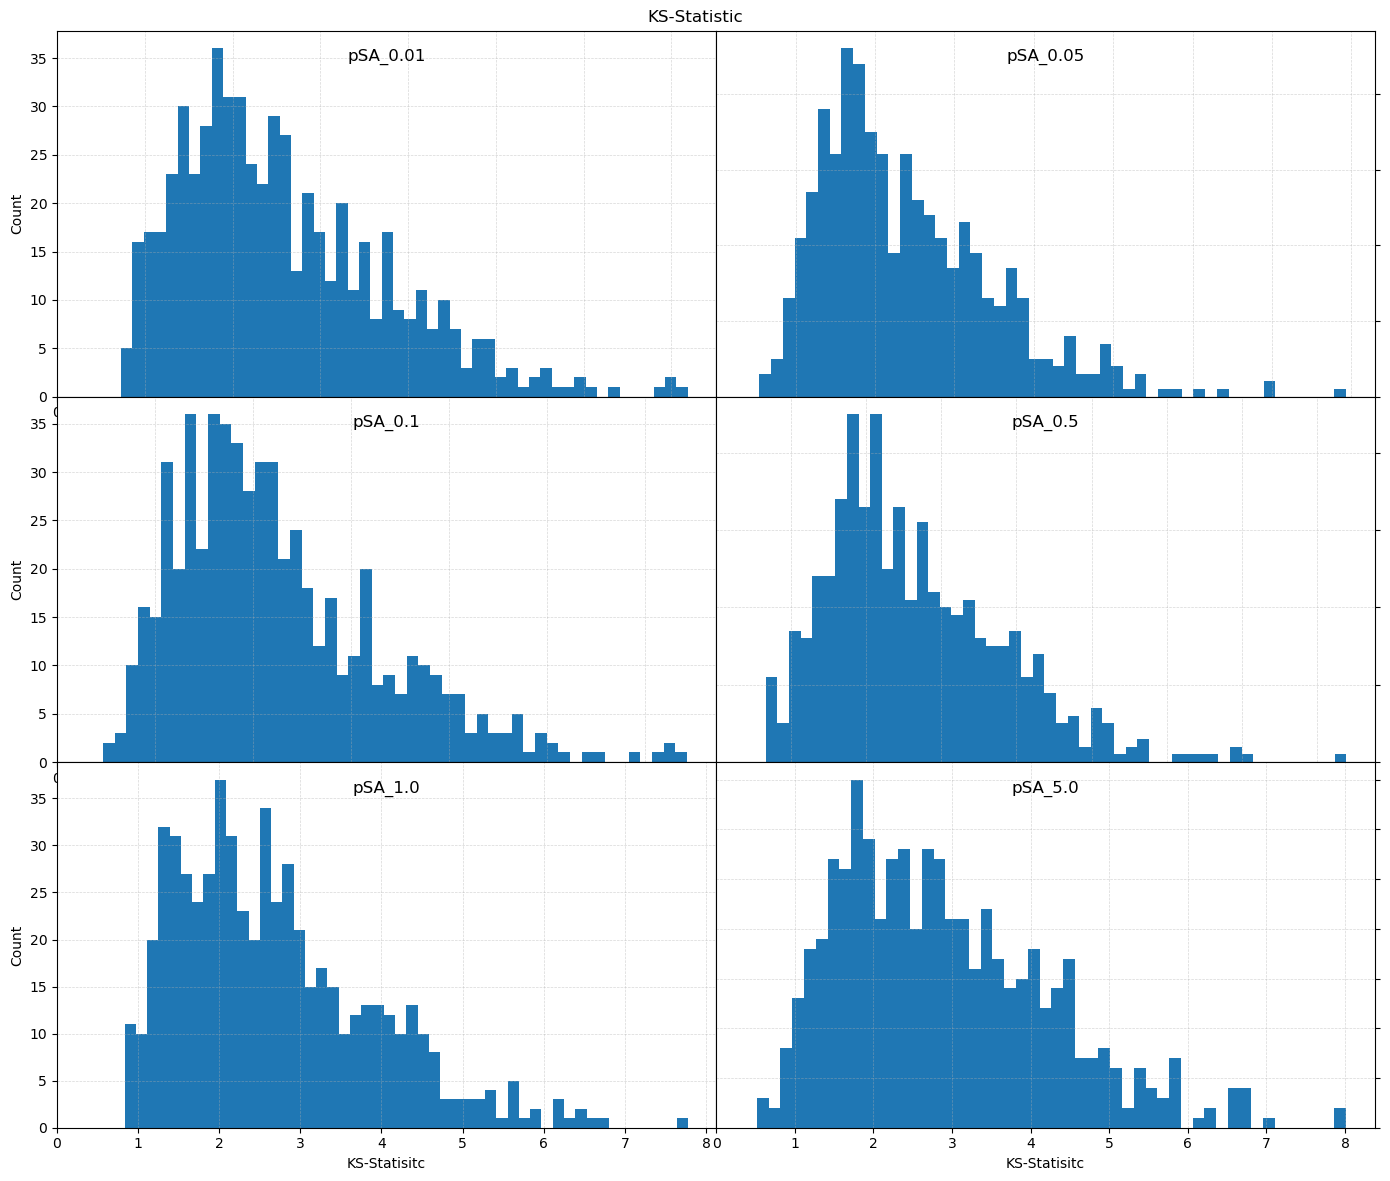

In [32]:
ims = ["pSA_0.01", "pSA_0.05", "pSA_0.1", "pSA_0.5", "pSA_1.0", "pSA_5.0"]

fig, axs = plt.subplots(3, 2, figsize=(14, 12))

for ix, (cur_ax, cur_im) in enumerate(zip(axs.ravel(), ims)):
	# cur_ax.hist(ks_df[cur_im].loc[p_df[cur_im] < 0.1].values, bins=50)
	cur_ax.hist(ks_df[cur_im].values, bins=50)
	cur_ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")
	
	if ix >= 4:
		cur_ax.set_xlabel(f"KS-Statisitc")
	if ix % 2 == 0:
		cur_ax.set_ylabel(f"Count")
		
	if ix % 2 == 1:
		cur_ax.set_yticklabels([])
		cur_ax.yaxis.tick_right()

	cur_ax.set_xlim(0, None)
	
	cur_ax.text(0.5, 0.95, f"{cur_im}", horizontalalignment="center", verticalalignment="top", transform=cur_ax.transAxes, fontsize=12)
	
	
fig.suptitle("KS-Statistic")
fig.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)